## Aurora kWh using Harvest’s kWh steps

Same spike-clean and 15-minute steps as `harvest_kwh.ipynb`, but Aurora’s file is loaded here (not in `modules/`).

**Expected Aurora columns:** `datetime`, `meter_name`, `kwh`, `stuck`.

Aurora readings are often already on 15-minute times, so the two output CSVs may look the same. `load_aurora_kwh` lives in this notebook; after that, functions come from `modules/harvest_kwh.py` ([modules/README.md](../modules/README.md)).


In [23]:
# TODO: ask eileen if she wants to keep stuck rows or not
# note still makes two csvs even though they are the same because aurora meter
# readings are already at 15 min intervals, so no interpolation is needed

### Enter input

- **`data_path`** — Aurora kWh CSV (comma or tab).
- **`name`** — first part of output names (usually `aurora`).
- **`keep_stuck_rows`** — keep rows Aurora marked stuck (`False` drops them).
- **`run_spike_cleaning`** — run Harvest spike removal before interpolation.


In [ ]:
# output directory
output_dir = '../data/outputs/'

# Aurora data input csv
data_path = output_dir + 'eileen/all_kwh_long_format.csv'

##########################################################################

# processed kwh data name
name = 'aurora' # for file naming

# Keep stuck meter reading rows for now
keep_stuck_rows = False

# TODO:
# for test
run_spike_cleaning = True


### Imports


In [25]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os,sys
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

sys.path.append(os.path.abspath('..'))
import modules.harvest_kwh as hv_kwh # import self defined module
import modules.file_naming as fn # import self defined module

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Aurora loader

`load_aurora_kwh` is **not** in `modules/`. It reads Aurora’s format, renames `kwh` → `meter_reading`, and optionally drops `stuck` rows so `harvest_kwh` functions can run as usual.

**If columns fail:** headers are not `datetime`, `meter_name`, `kwh`, `stuck`.


In [ ]:
# Different loading function for Aurora kwh readings in case where 'stuck'
# is a column in the data
def load_aurora_kwh(data_path, keep_stuck_rows=True):
    """
    Load Aurora kWh readings and convert them into the same column format
    expected by the existing kWh processing functions.

    Aurora expected columns:
        datetime, meter_name, kwh, stuck

    Notes:
        - kwh is renamed to meter_reading
        - stuck rows are kept when keep_stuck_rows=True
        - comma or tab-delimited files should both work
    """
    df = pd.read_csv(
        data_path,
        sep=None,
        engine='python',
        encoding='utf-8',
        low_memory=False,
    )

    # clean column names in case the file has spaces around headers
    df.columns = df.columns.str.strip()

    # rename kwh to meter_reading so the existing functions still work
    if 'kwh' in df.columns and 'meter_reading' not in df.columns:
        df.rename(columns={'kwh': 'meter_reading'}, inplace=True)

    required_cols = ['datetime', 'meter_name', 'meter_reading']
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}. Current columns: {list(df.columns)}')

    df['datetime'] = pd.to_datetime(
        df['datetime'],
        format='%Y-%m-%d %H:%M:%S',
        errors='coerce'
    )

    df['meter_name'] = df['meter_name'].astype(str).str.strip().str.lower()

    df['meter_reading'] = pd.to_numeric(
        df['meter_reading'],
        errors='coerce'
    )

    # Keep stuck rows for now, but make the column numeric if it exists
    if 'stuck' in df.columns:
        df['stuck'] = pd.to_numeric(df['stuck'], errors='coerce').fillna(0)

        if not keep_stuck_rows:
            df = df[df['stuck'] != 1].copy()

    # Drop rows that cannot be used at all
    df = df.dropna(subset=['datetime', 'meter_name', 'meter_reading']).reset_index(drop=True)

    return df


### Load, clean, interpolate, and save

Prints row count, meters, date range, and stuck counts so you can sanity-check before writing files.


In [ ]:
# var for file naming
var = 'kwh'
var2 = 'kwh_15min' # for only kwh data on 15 min intervals

# load Aurora kwh data
loaded_kwh = load_aurora_kwh(data_path, keep_stuck_rows=keep_stuck_rows)

###########################################################################
print('Loaded rows:', len(loaded_kwh))
print('Columns:', list(loaded_kwh.columns))
print('Meters:', loaded_kwh['meter_name'].nunique())
print('Date range:', loaded_kwh['datetime'].min(), 'to', loaded_kwh['datetime'].max())

if 'stuck' in loaded_kwh.columns:
    print('Stuck value counts:')
    print(loaded_kwh['stuck'].value_counts(dropna=False).sort_index())
###########################################################################

# remove bad spike rows before interpolation, if selected
if run_spike_cleaning:
    clean_kwh = hv_kwh.clean_kwh_spikes(loaded_kwh)
else:
    clean_kwh = loaded_kwh.copy()

print('Rows after optional cleaning:', len(clean_kwh))

# processing kwh/interpolation
processed_kwh = hv_kwh.process_kwh(clean_kwh)

# create copy of dataframe with only kwh data on 15 min intervals
int_processed_kwh = hv_kwh.interval_kwh(processed_kwh)

# create kwh filenames
kwh_filename = output_dir + fn.make_filename(processed_kwh, name, var, 'csv')
int_kwh_filename = output_dir + fn.make_filename(processed_kwh, name, var2, 'csv')

# convert dataframes to csv
processed_kwh.to_csv(kwh_filename, index=False)
int_processed_kwh.to_csv(int_kwh_filename, index=False)


Loaded rows: 365947
Columns: ['datetime', 'meter_name', 'meter_reading', 'stuck']
Meters: 141
Date range: 2026-05-13 12:00:00 to 2026-06-16 11:45:00
Stuck value counts:
stuck
0    365947
Name: count, dtype: int64
Rows after optional cleaning: 365947


---

### Optional checks

Not required for the CSV outputs. First cell: how many Aurora rows are **not** on :00/:15/:30/:45. Next cells: plot processed 15-minute readings to a PDF (only the first few meters display in the notebook).


In [28]:
# quick aurora interval check
non_quarter_hour_rows = loaded_kwh[~loaded_kwh['datetime'].dt.minute.isin([0, 15, 30, 45])]
print('Non-quarter-hour rows:', len(non_quarter_hour_rows))

Non-quarter-hour rows: 0


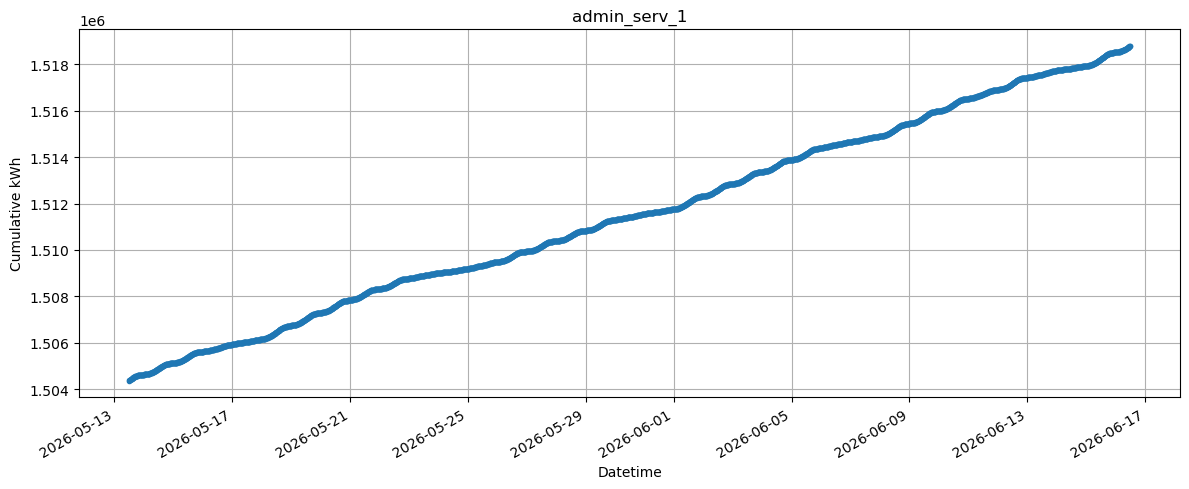

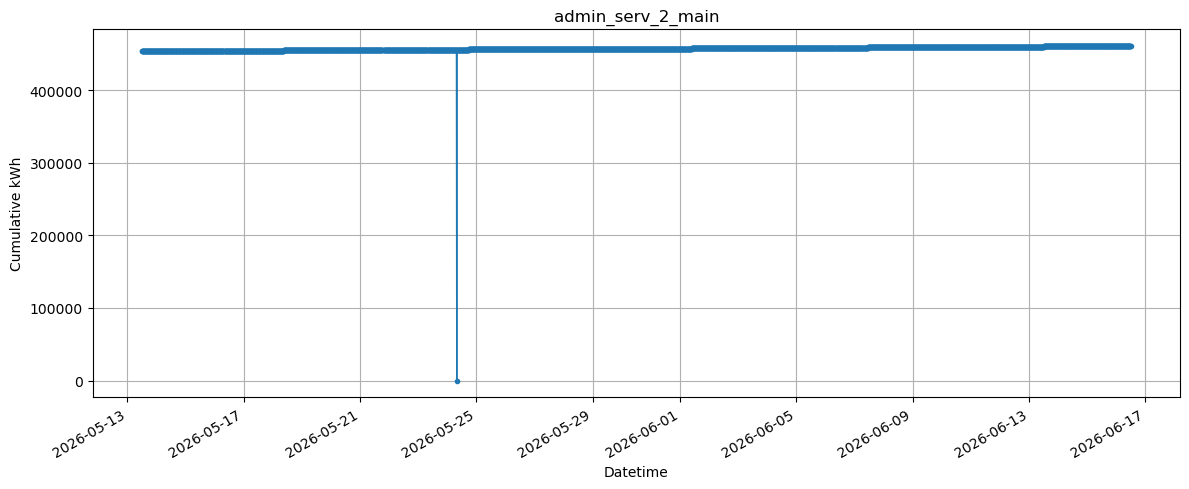

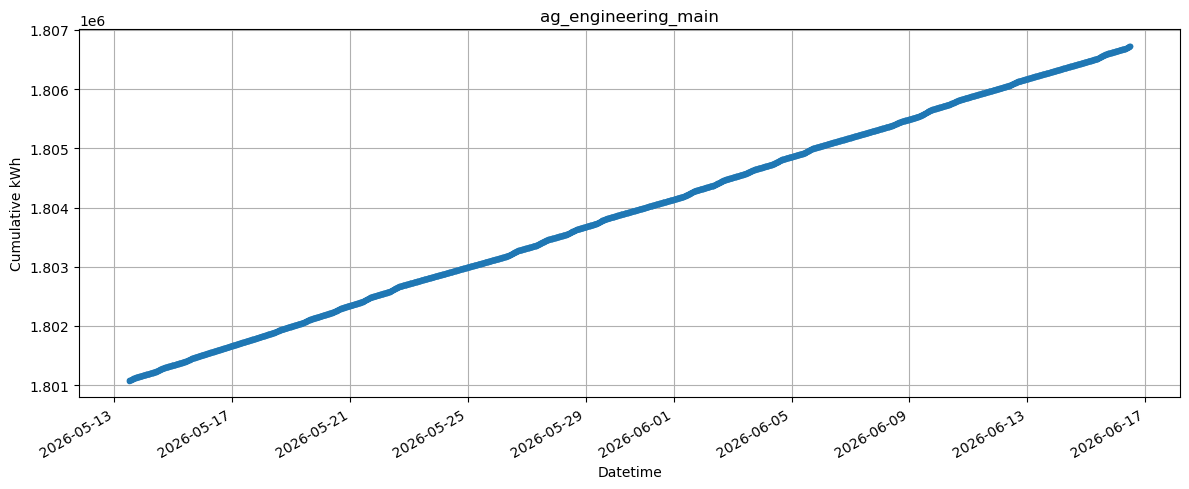

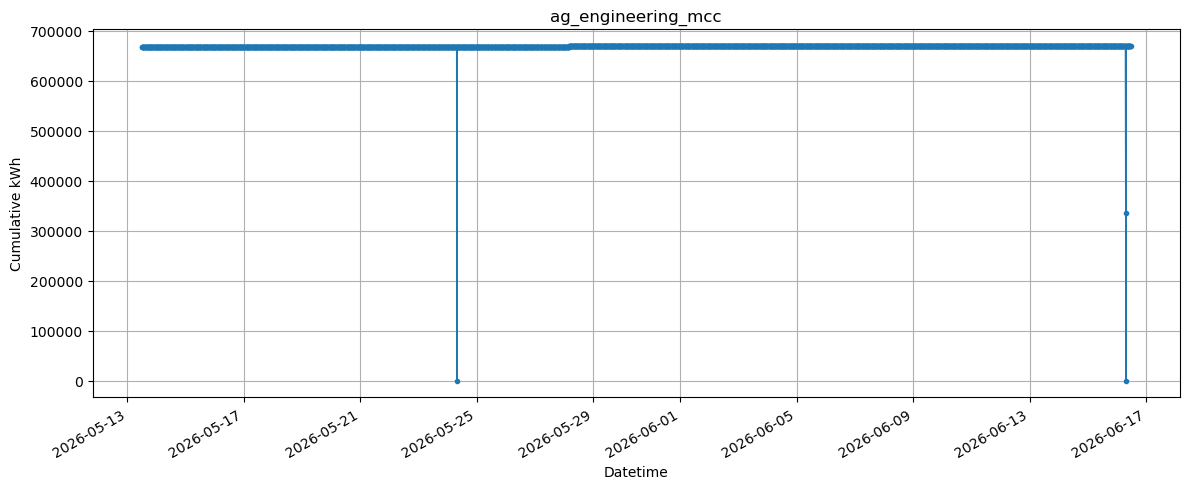

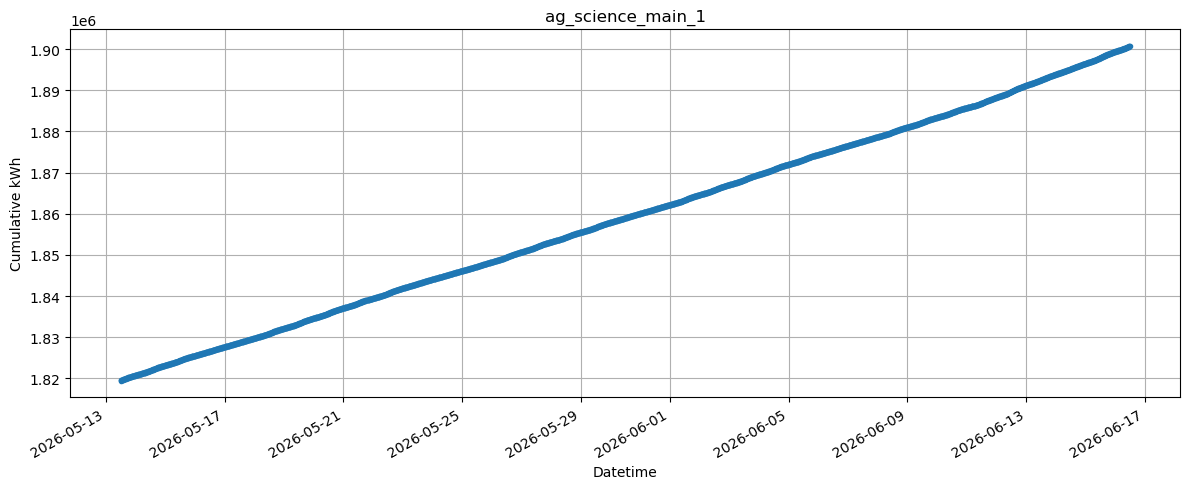

In [31]:
# Use the processed 15-minute kwh dataframe
plot_df = int_processed_kwh.copy()

# Make sure columns are clean for plotting
plot_df["datetime"] = pd.to_datetime(plot_df["datetime"], errors="coerce")
plot_df["meter_reading"] = pd.to_numeric(plot_df["meter_reading"], errors="coerce")

# Drop rows that cannot be graphed
plot_df = plot_df.dropna(subset=["datetime", "meter_name", "meter_reading"])

# Sort so graph lines connect correctly
plot_df = plot_df.sort_values(["meter_name", "datetime"]).reset_index(drop=True)

# PDF output file
plot_pdf_file = f"{var}_processed_aurora_meter_reading_plots.pdf"

# Only show first few graphs in notebook so it does not spam you
show_first_n_meters = 5

meter_names = sorted(plot_df["meter_name"].unique())

with PdfPages(plot_pdf_file) as pdf:
    for i, meter_name in enumerate(meter_names):
        meter_df = plot_df[plot_df["meter_name"] == meter_name].copy()

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(
            meter_df["datetime"],
            meter_df["meter_reading"],
            marker=".",
            linewidth=1
        )

        # Keep stuck rows and mark them visually if the column exists
        if "stuck" in meter_df.columns:
            stuck_values = pd.to_numeric(meter_df["stuck"], errors="coerce").fillna(0)
            stuck_df = meter_df[stuck_values != 0]

            if not stuck_df.empty:
                ax.scatter(
                    stuck_df["datetime"],
                    stuck_df["meter_reading"],
                    marker="x",
                    s=60,
                    label="stuck != 0",
                    color="red"
                )
                ax.legend()

        ax.set_title(f"{meter_name}")
        ax.set_xlabel("Datetime")
        ax.set_ylabel("Cumulative kWh")
        ax.grid(True)

        fig.autofmt_xdate()
        plt.tight_layout()

        # Save every graph to the PDF
        pdf.savefig(fig)

        # Show only first few in notebook
        if i < show_first_n_meters:
            plt.show()
        else:
            plt.close(fig)